#### Plot scores across one prompt type

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data(file_path):
    """
    Reads the CSV file and returns a pandas DataFrame.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"Successfully loaded data from {file_path}")
        return df
    except FileNotFoundError:
        print(f"Error: The file {file_path} was not found.")
        return None


def plot_scores(df, prompt_type):
    """
    Filters data by prompt_type, sorts by Final Score, and generates a bar chart.
    Dynamically adjusts the figure width to ensure bars and labels are spaced out.
    Includes both the Optimal Layer on top and the Final Score at the bottom.
    """
    # Filter the data based on the prompt type
    filtered_df = df[df['Prompt Type'] == prompt_type].copy()
    
    if filtered_df.empty:
        print(f"No data found for Prompt Type: {prompt_type}")
        return

    # Sort the data by 'Final Score' (descending order)
    sorted_df = filtered_df.sort_values(by='Final Score', ascending=False)


    num_bars = len(sorted_df)
    dynamic_width = max(12, num_bars * 0.35) 
    
    # Set up the plot with the dynamic width
    fig, ax = plt.subplots(figsize=(dynamic_width, 8)) 
    
    # Create the bars
    bars = ax.bar(sorted_df['Concept'], sorted_df['Final Score'], color='steelblue', edgecolor='black')

    # Format the X-axis to have vertical labels
    plt.xticks(rotation=90, fontsize=10)
    
    # Set labels and title
    ax.set_xlabel('Concept', fontsize=12, fontweight='bold')
    ax.set_ylabel('Final Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Final Scores by Concept (Prompt Type {prompt_type})', fontsize=14, fontweight='bold')

    # Display the labels on the bars
    for bar, layer in zip(bars, sorted_df['Optimal Layer']):
        height = bar.get_height()
        
        # 1. Optimal Layer at the top
        layer_text = str(int(layer)) if pd.notna(layer) else "N/A" 
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            max(height, 0.075),                            
            layer_text,                        
            ha='center',                       
            va='bottom',                       
            fontsize=9,
            color='black'
        )

        smart_color = 'white' if height > 0.065 else 'black'

        # 2. Final Score at the bottom, vertically
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            0.01,                           
            f"{height:.5f}",             
            ha='center',                       
            va='bottom',                       
            rotation=90,                   
            fontsize=9,
            color= smart_color
        )

        
    plt.tight_layout()

    # Save and display
    plt.savefig(f"concept_scores_plot_type{prompt_type}.png", bbox_inches="tight")
    plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\oribr\AppData\Local\Temp\ipykernel_19560\3784147103.py:2: SyntaxWarning: invalid escape sequence '\c'
  file_name = '..\\results\concept_steerability_results\\bert_scores.csv'


Successfully loaded data from ..\results\concept_steerability_results\bert_scores.csv


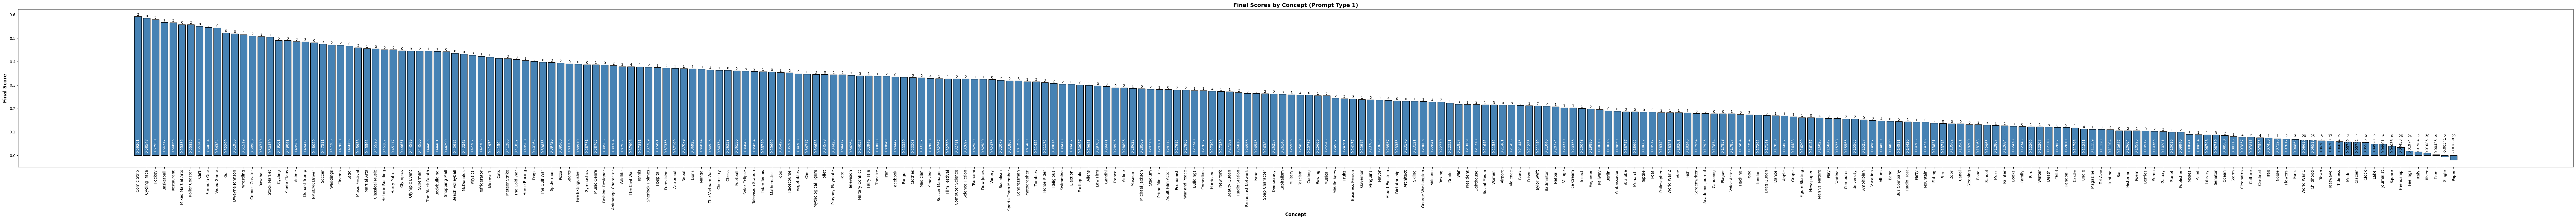

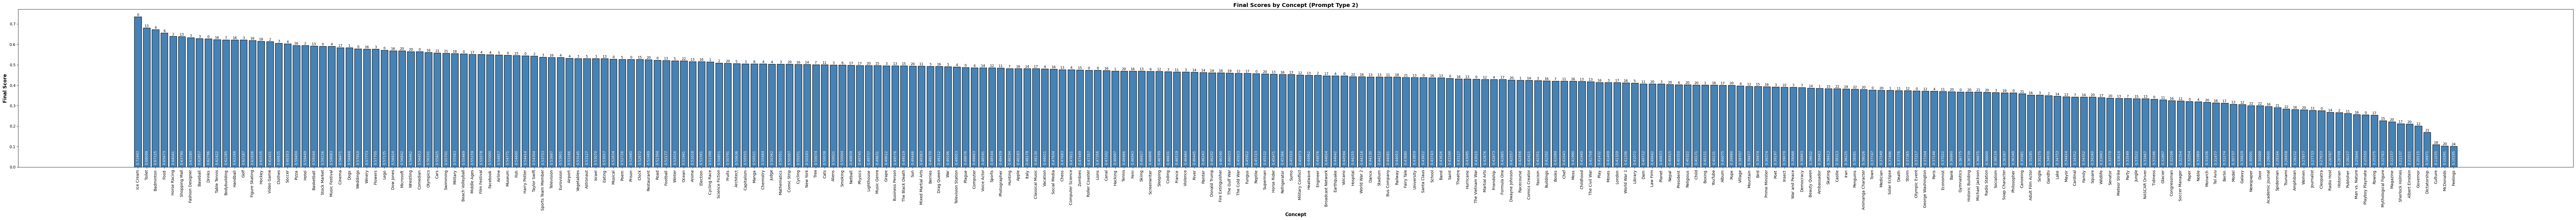

In [ ]:
file_name = '..\\results\concept_steerability_results\\bert_scores.csv' 

results_df = load_data(file_name)

plot_scores(results_df, prompt_type=1)
plot_scores(results_df, prompt_type=2)